In [1]:
# importing libraries

# standard libraries
from pathlib import Path
import joblib
import warnings

# data handling
import pandas as pd
import numpy as np

# chemistry
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdFingerprintGenerator

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# ML - preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold, SelectKBest, RFE

# ML - model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

# ML - models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ML - metrics
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    matthews_corrcoef,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc
)

In [2]:
# function to save plots in directory

PLOT_DIR = Path("results/plots")

def save_plot(name, path=PLOT_DIR):
    path.mkdir(parents=True, exist_ok=True)
    plt.savefig(path / f"{name}.png")

In [3]:
# colormap for matplotlib

cmap = "viridis"

In [4]:
# seed for reproducibility of data

seed = 23

In [5]:
# reading dataset

!mkdir -p data/raw && \
wget -O data/raw/tox21.csv.gz https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz

tox21_df = pd.read_csv("data/raw/tox21.csv.gz")

--2026-04-26 19:13:59--  https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving deepchemdata.s3-us-west-1.amazonaws.com (deepchemdata.s3-us-west-1.amazonaws.com)... 52.219.113.106, 52.219.220.154, 16.15.4.24, ...
Connecting to deepchemdata.s3-us-west-1.amazonaws.com (deepchemdata.s3-us-west-1.amazonaws.com)|52.219.113.106|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122925 (120K) [application/x-gzip]
Saving to: ‘data/raw/tox21.csv.gz’

data/raw/tox21.csv. 100%[===================>] 120.04K   280KB/s    in 0.4s    

2026-04-26 19:14:00 (280 KB/s) - ‘data/raw/tox21.csv.gz’ saved [122925/122925]



## **Dataset preparation**

In [6]:
tox21_df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [7]:
tox21_df.shape

(7831, 14)

In [8]:
# filtering molecules not processed by MolFromSmiles function

df = tox21_df[tox21_df["smiles"].apply(lambda x: Chem.MolFromSmiles(x) is not None)].reset_index(drop=True)

[19:14:01] WARNING: not removing hydrogen atom without neighbors
[19:14:01] Explicit valence for atom # 8 Al, 6, is greater than permitted
[19:14:01] Explicit valence for atom # 3 Al, 6, is greater than permitted
[19:14:01] Explicit valence for atom # 4 Al, 6, is greater than permitted
[19:14:01] Explicit valence for atom # 4 Al, 6, is greater than permitted
[19:14:01] Explicit valence for atom # 9 Al, 6, is greater than permitted
[19:14:01] Explicit valence for atom # 5 Al, 6, is greater than permitted
[19:14:01] Explicit valence for atom # 16 Al, 6, is greater than permitted
[19:14:01] Explicit valence for atom # 20 Al, 6, is greater than permitted


In [9]:
df.shape

(7823, 14)

In [10]:
df["mol_id"].nunique()

7823

Example of 3 random molecules from the dataset:


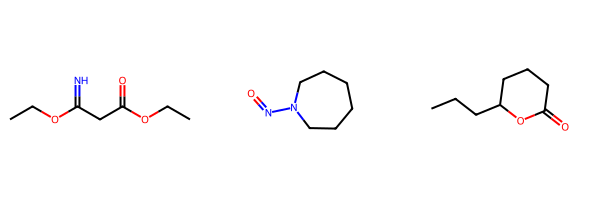

In [11]:
print("Example of 3 random molecules from the dataset:")

mols = [Chem.MolFromSmiles(s) for s in df["smiles"].sample(n=3)]
Draw.MolsToGridImage(mols)

In [12]:
df.columns

Index(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
       'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53',
       'mol_id', 'smiles'],
      dtype='str')

In [13]:
targets = df.columns[:-2]

print("The bioassays are: ")
for i in range(len(targets)):
  print(f"{i+1}. {targets[i]}")

The bioassays are: 
1. NR-AR
2. NR-AR-LBD
3. NR-AhR
4. NR-Aromatase
5. NR-ER
6. NR-ER-LBD
7. NR-PPAR-gamma
8. SR-ARE
9. SR-ATAD5
10. SR-HSE
11. SR-MMP
12. SR-p53


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7823 entries, 0 to 7822
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7258 non-null   float64
 1   NR-AR-LBD      6751 non-null   float64
 2   NR-AhR         6542 non-null   float64
 3   NR-Aromatase   5815 non-null   float64
 4   NR-ER          6186 non-null   float64
 5   NR-ER-LBD      6948 non-null   float64
 6   NR-PPAR-gamma  6443 non-null   float64
 7   SR-ARE         5825 non-null   float64
 8   SR-ATAD5       7065 non-null   float64
 9   SR-HSE         6460 non-null   float64
 10  SR-MMP         5804 non-null   float64
 11  SR-p53         6767 non-null   float64
 12  mol_id         7823 non-null   str    
 13  smiles         7823 non-null   str    
dtypes: float64(12), str(2)
memory usage: 855.8 KB


## **Exploratory Data Analysis**

In [15]:
df.isnull().sum()

NR-AR             565
NR-AR-LBD        1072
NR-AhR           1281
NR-Aromatase     2008
NR-ER            1637
NR-ER-LBD         875
NR-PPAR-gamma    1380
SR-ARE           1998
SR-ATAD5          758
SR-HSE           1363
SR-MMP           2019
SR-p53           1056
mol_id              0
smiles              0
dtype: int64

In [16]:
for target in targets:
    data_counts = df.groupby(target).size()
    print(data_counts)

NR-AR
0.0    6950
1.0     308
dtype: int64
NR-AR-LBD
0.0    6514
1.0     237
dtype: int64
NR-AhR
0.0    5774
1.0     768
dtype: int64
NR-Aromatase
0.0    5515
1.0     300
dtype: int64
NR-ER
0.0    5395
1.0     791
dtype: int64
NR-ER-LBD
0.0    6599
1.0     349
dtype: int64
NR-PPAR-gamma
0.0    6257
1.0     186
dtype: int64
SR-ARE
0.0    4883
1.0     942
dtype: int64
SR-ATAD5
0.0    6801
1.0     264
dtype: int64
SR-HSE
0.0    6088
1.0     372
dtype: int64
SR-MMP
0.0    4886
1.0     918
dtype: int64
SR-p53
0.0    6344
1.0     423
dtype: int64


In [17]:
# summary of dataset

summary = []

for target in targets:
    not_toxic = (df[target] == 0).sum()
    toxic = (df[target] == 1).sum()
    nan = (df[target]).isnull().sum()

    total = not_toxic + toxic + nan
    valid_total = not_toxic + toxic

    summary.append({
        "Target": target, 
        "Not Toxic": not_toxic,
        "Toxic": toxic,
        "Missing": nan,
        "Toxic % (on valid)": (toxic / valid_total) * 100,
        "Not Toxic % (on valid)": (not_toxic / valid_total) * 100,
        "Missing % (on total)": (nan / total * 100)
        })

summary_df = pd.DataFrame(summary)

In [18]:
counts_df = summary_df[["Target", "Not Toxic", "Toxic", "Missing"]]
print(counts_df)

           Target  Not Toxic  Toxic  Missing
0           NR-AR       6950    308      565
1       NR-AR-LBD       6514    237     1072
2          NR-AhR       5774    768     1281
3    NR-Aromatase       5515    300     2008
4           NR-ER       5395    791     1637
5       NR-ER-LBD       6599    349      875
6   NR-PPAR-gamma       6257    186     1380
7          SR-ARE       4883    942     1998
8        SR-ATAD5       6801    264      758
9          SR-HSE       6088    372     1363
10         SR-MMP       4886    918     2019
11         SR-p53       6344    423     1056


In [19]:
# printing missing values

missing_df = summary_df[["Target", "Missing % (on total)"]]

print(
    missing_df
    .sort_values(by="Missing % (on total)", ascending=False)
    .to_string(formatters={
        "Missing % (on total)": lambda x: f"{x:.2f}"
    })
)

           Target Missing % (on total)
10         SR-MMP                25.81
3    NR-Aromatase                25.67
7          SR-ARE                25.54
4           NR-ER                20.93
6   NR-PPAR-gamma                17.64
9          SR-HSE                17.42
2          NR-AhR                16.37
1       NR-AR-LBD                13.70
11         SR-p53                13.50
5       NR-ER-LBD                11.18
8        SR-ATAD5                 9.69
0           NR-AR                 7.22


In [20]:
# printing class distribution between toxic and not toxic

balance_df = summary_df[["Target", "Toxic % (on valid)", "Not Toxic % (on valid)"]]

print(
    balance_df
    .sort_values(by="Toxic % (on valid)", ascending=False)
    .to_string(formatters={
        "Toxic % (on valid)": lambda x: f"{x:.2f}%",
        "Not Toxic % (on valid)": lambda x: f"{x:.2f}%",
    })
)

           Target Toxic % (on valid) Not Toxic % (on valid)
7          SR-ARE             16.17%                 83.83%
10         SR-MMP             15.82%                 84.18%
4           NR-ER             12.79%                 87.21%
2          NR-AhR             11.74%                 88.26%
11         SR-p53              6.25%                 93.75%
9          SR-HSE              5.76%                 94.24%
3    NR-Aromatase              5.16%                 94.84%
5       NR-ER-LBD              5.02%                 94.98%
0           NR-AR              4.24%                 95.76%
8        SR-ATAD5              3.74%                 96.26%
1       NR-AR-LBD              3.51%                 96.49%
6   NR-PPAR-gamma              2.89%                 97.11%


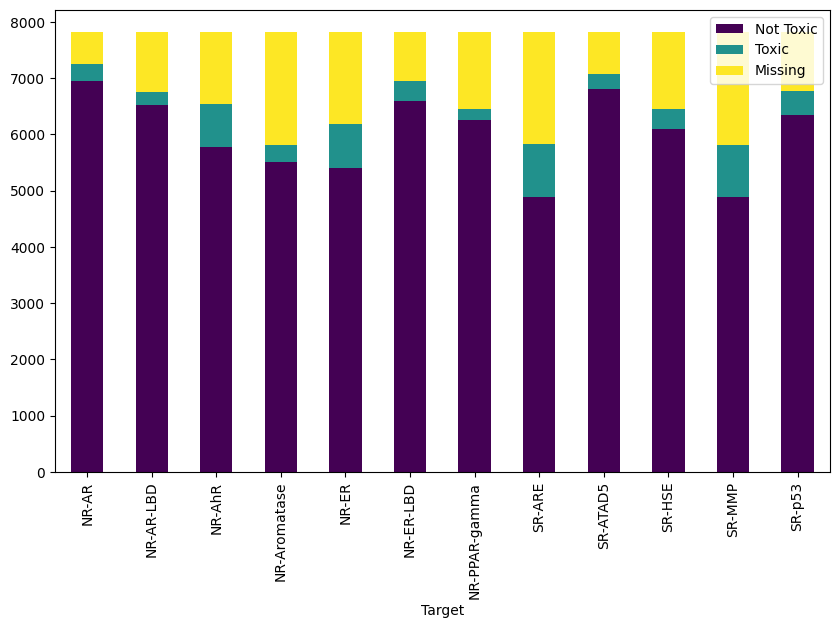

In [21]:
# visualizing classes distributions

ax = counts_df.set_index("Target").plot.bar(stacked=True, figsize=(10, 6), cmap=cmap)
fig = ax.get_figure()
save_plot("class-distribution")
plt.show()

In [22]:
# using only NR-AhR as our target

NR_AhR_df = df[["NR-AhR", "smiles"]].dropna().reset_index(drop=True)
print(NR_AhR_df)

      NR-AhR                                             smiles
0        1.0                       CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1        0.0                          CCN1C(=O)NC(c2ccccc2)C1=O
2        0.0                    CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
3        0.0                          CC(O)(P(=O)(O)O)P(=O)(O)O
4        0.0               CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C
...      ...                                                ...
6537     0.0                     CCCn1c(=O)[nH]c(=O)c2[nH]cnc21
6538     0.0                 CCCNCC(O)COc1ccccc1C(=O)CCc1ccccc1
6539     0.0  CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...
6540     0.0  C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@@]43C)[C...
6541     0.0  C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...

[6542 rows x 2 columns]


In [23]:
y = NR_AhR_df["NR-AhR"]
print(y)

0       1.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
6537    0.0
6538    0.0
6539    0.0
6540    0.0
6541    0.0
Name: NR-AhR, Length: 6542, dtype: float64


## **Feature extraction of molecular descriptors**

In [24]:
# extracting molecular descriptors

desc_names = [x[0] for x in Descriptors.descList]
desc_funcs = [x[1] for x in Descriptors.descList]

all_desc_values = []

for smiles in NR_AhR_df["smiles"]:
    mol = Chem.MolFromSmiles(smiles)
    desc_values = [f(mol) for f in desc_funcs]
    all_desc_values.append(desc_values)

desc_df = pd.DataFrame(all_desc_values, columns=desc_names)
desc_df.head()

[19:14:02] WARNING: not removing hydrogen atom without neighbors
[19:14:02] WARNING: not removing hydrogen atom without neighbors


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.107593,11.107593,0.073011,-3.723219,0.900283,11.875000,258.324,248.244,258.013284,86,...,0,1,0,0,0,1,0,0,0,0
1,11.790004,11.790004,0.172500,-0.515139,0.738013,20.600000,204.229,192.133,204.089878,78,...,0,0,0,0,0,0,0,0,0,1
2,12.570517,12.570517,0.042633,-0.042633,0.822261,12.500000,276.424,248.200,276.220164,112,...,0,0,0,0,0,0,0,0,0,0
3,10.251875,10.251875,0.383488,-5.197724,0.365583,15.090909,206.027,197.963,205.974526,68,...,0,0,0,0,0,0,0,0,0,0
4,5.538351,5.538351,0.306911,-0.365434,0.497486,14.700000,290.444,256.172,290.245710,122,...,0,0,0,0,0,0,0,0,0,0


In [25]:
desc_df.shape

(6542, 217)

In [26]:
# delete infinite features

mask = np.isfinite(desc_df).all()

desc_df_clean = desc_df.loc[:, mask]

In [27]:
desc_df_clean.shape

(6542, 205)

In [28]:
desc_df_clean.columns

Index(['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex',
       'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt',
       'NumValenceElectrons',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=205)

In [29]:
# top 10 features based on MI

mi_scores = mutual_info_classif(desc_df_clean, y, random_state=seed)

mi_df = pd.DataFrame({
    "feature": desc_df_clean.columns,
    "mi_score": mi_scores
}).sort_values(by="mi_score", ascending=False)

top10_features = mi_df.head(10)["feature"].tolist()

print(mi_df.head(10))

              feature  mi_score
50          SMR_VSA10  0.076248
56           SMR_VSA7  0.071567
93       FractionCSP3  0.059922
67         SlogP_VSA6  0.053694
103  NumAromaticRings  0.052198
17               Chi0  0.049013
89        VSA_EState6  0.048322
69         SlogP_VSA8  0.045902
71               TPSA  0.045673
29      HallKierAlpha  0.044304


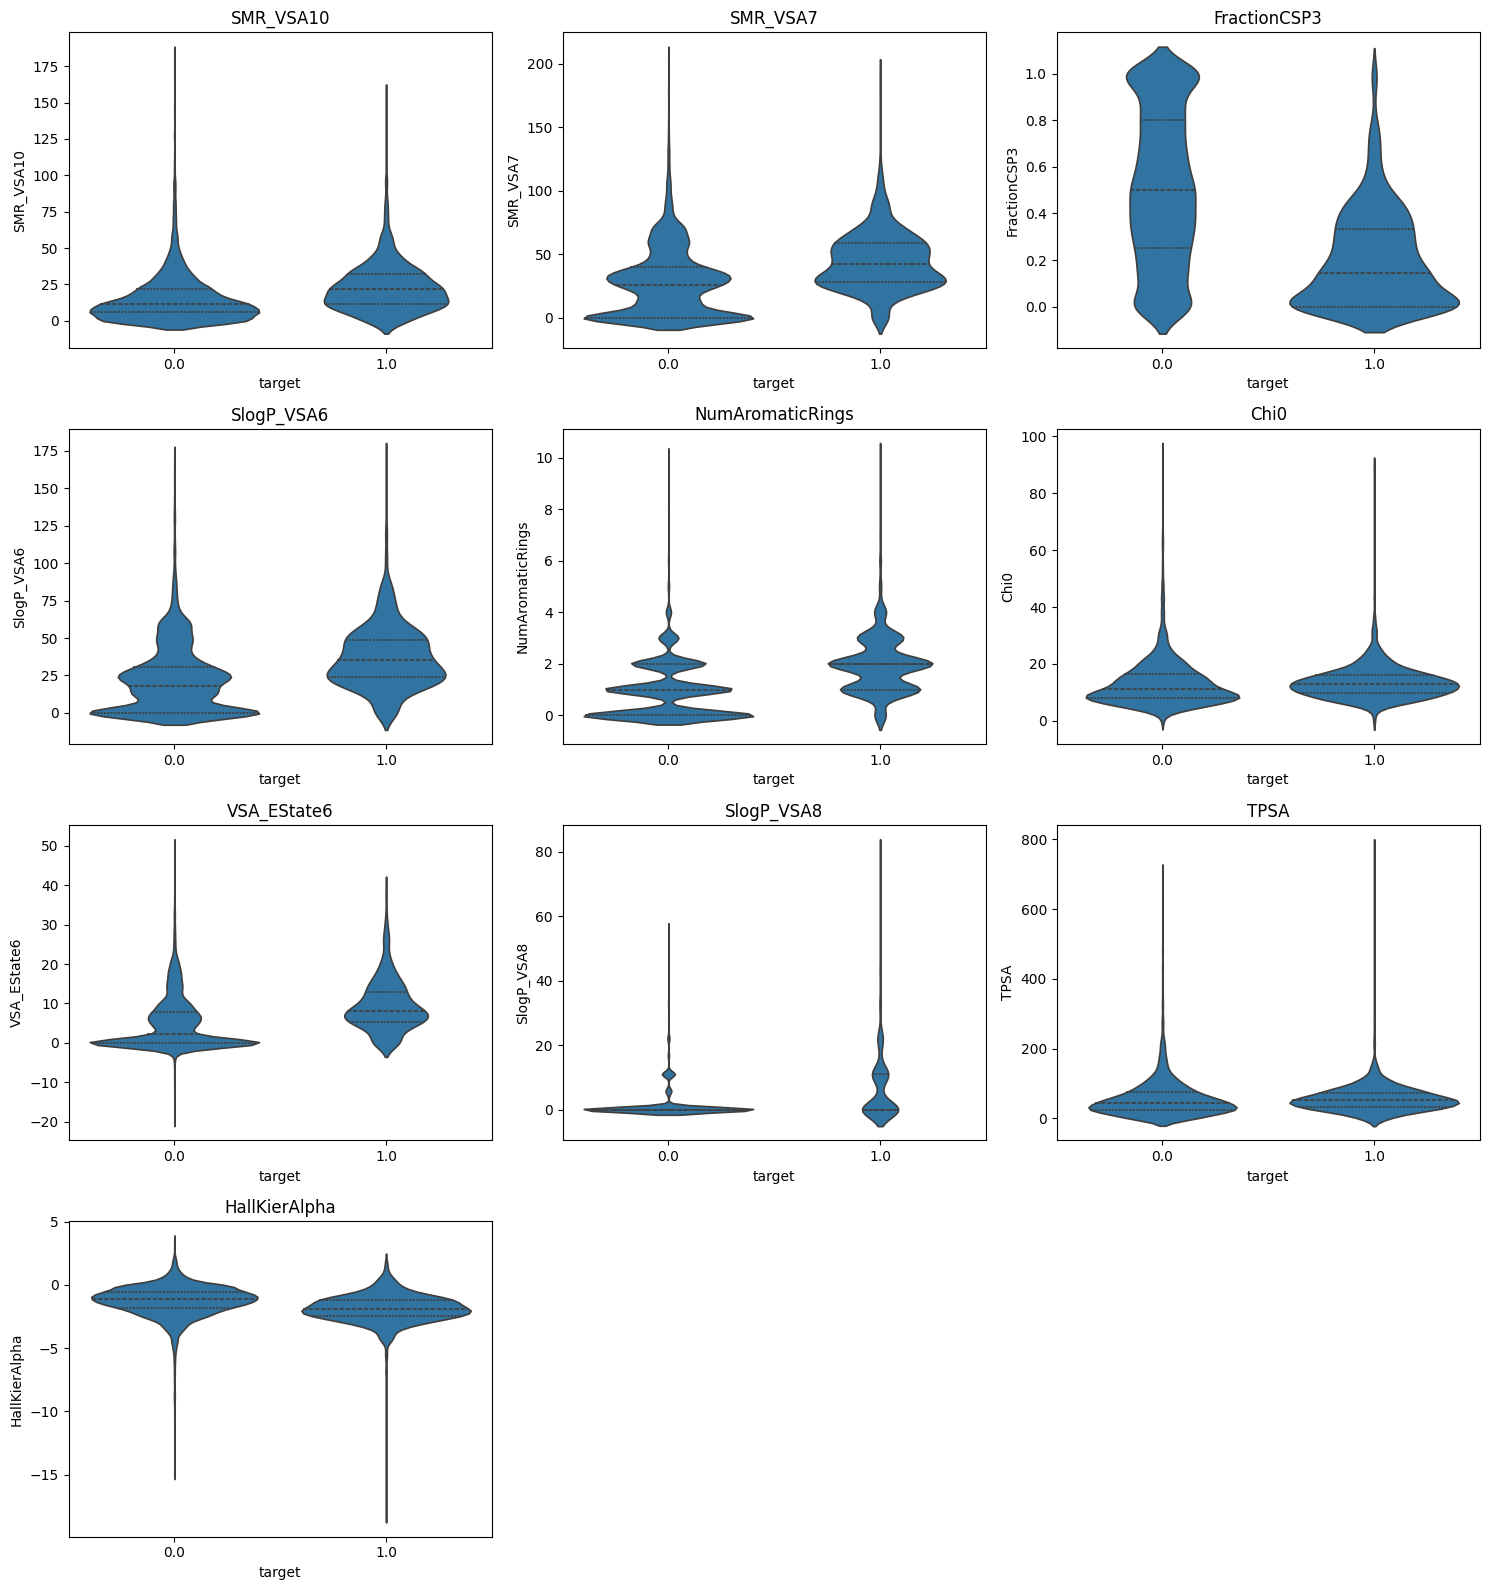

In [30]:
# visualizing feature distribution grouped by class of top 10 features based on MI

X_top10 = desc_df_clean[top10_features].copy()
X_top10["target"] = y.values

n_cols = 3
n_rows = (len(top10_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(top10_features):
    sns.violinplot(
        cmap=cmap,
        data=X_top10,
        x="target",
        y=feature,
        ax=axes[i],
        inner="quartile"
    )
    axes[i].set_title(feature)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
save_plot("top10-feature-distro-violin-plot")
plt.show()

In [31]:
# printing higly correlated pairs of features

threshold = 0.95

corr = desc_df.corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

corr_pairs = (
    upper.stack()
    .reset_index()
)

corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr_pairs = corr_pairs[
    corr_pairs["Correlation"].abs() > threshold
]

high_corr_pairs = high_corr_pairs.sort_values(
    by="Correlation",
    ascending=False
)

print(f"Highly correlated feature pairs (Pearson Coefficient > {threshold}):")
print("="*30)
for a, b, val in high_corr_pairs.values:
    print(f"{a} - {b}: {val:.3f}")

Highly correlated feature pairs (Pearson Coefficient > 0.95):
MaxAbsEStateIndex - MaxEStateIndex: 1.000
NumAmideBonds - fr_amide: 1.000
fr_Ar_NH - fr_Nhpyrrole: 1.000
MolWt - ExactMolWt: 1.000
Kappa2 - Phi: 1.000
Chi1 - HeavyAtomCount: 0.999
MolWt - HeavyAtomMolWt: 0.998
HeavyAtomMolWt - ExactMolWt: 0.998
NumAromaticCarbocycles - fr_benzene: 0.998
Chi0 - HeavyAtomCount: 0.997
NumValenceElectrons - Chi0: 0.997
fr_COO - fr_COO2: 0.996
NumValenceElectrons - HeavyAtomCount: 0.995
Chi0 - Chi1: 0.994
LabuteASA - HeavyAtomCount: 0.994
Chi0n - Chi1n: 0.993
Chi1 - LabuteASA: 0.993
NumValenceElectrons - Chi1: 0.993
Chi0v - LabuteASA: 0.992
Chi0 - LabuteASA: 0.992
NumValenceElectrons - LabuteASA: 0.991
fr_phenol - fr_phenol_noOrthoHbond: 0.990
LabuteASA - MolMR: 0.989
Chi3n - Chi4n: 0.989
Chi0v - MolMR: 0.989
NumValenceElectrons - Chi0n: 0.988
fr_Ar_OH - fr_phenol: 0.988
Chi0n - Chi1: 0.984
Chi0n - HeavyAtomCount: 0.984
Chi0n - MolMR: 0.984
Chi0n - Chi0v: 0.984
Chi1 - MolMR: 0.983
NumValenceElect

In [32]:
print(len(high_corr_pairs))

94


## **Feature selection of molecular descriptors**

In [33]:
# train/test split (indexes)

X_desc = desc_df_clean.copy()
y = NR_AhR_df["NR-AhR"]

train_idx, test_idx = train_test_split(
    X_desc.index,
    test_size=0.2,
    random_state=seed,
    stratify=y
)

In [34]:
# train/test split (desc_X)

desc_X_train = X_desc.loc[train_idx]
desc_X_test = X_desc.loc[test_idx]

In [35]:
# train/test split (y)

y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

In [36]:
# check stratify

control = pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Train": y_train.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True),
})

print(control)

        Original     Train      Test
NR-AhR                              
0.0     0.882605  0.882668  0.882353
1.0     0.117395  0.117332  0.117647


In [37]:
# scaling features

scaler = StandardScaler()
scaler.set_output(transform="pandas")

desc_X_train_scaled = scaler.fit_transform(desc_X_train)
desc_X_test_scaled = scaler.transform(desc_X_test)

In [38]:
# check the scaling

print(f'Mean train original: {desc_X_train.mean().mean()}')
print(f'Mean train scaled: {desc_X_train_scaled.mean().mean()} (should be near 0)')
print(f'Std train original: {desc_X_train.std().mean()}')
print(f'Std train scaled: {desc_X_train_scaled.std().mean()} (should be near 1)')

Mean train original: 1.0648117520130528e+35
Mean train scaled: -7.805760013547033e-18 (should be near 0)
Std train original: 7.702684590843208e+36
Std train scaled: 0.9854600163854618 (should be near 1)


In [39]:
desc_X_train_scaled.shape

(5233, 205)

In [40]:
# delete constant features

vt = VarianceThreshold(0.0)
vt.set_output(transform="pandas")

desc_X_train_vt = vt.fit_transform(desc_X_train_scaled)
desc_X_test_vt = vt.transform(desc_X_test_scaled)


In [41]:
desc_X_train_vt.shape

(5233, 202)

In [42]:
# evaluate optimal k value of features based on PR-AUC via UN

n_features = desc_X_train_vt.shape[1]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

results_UN = []
k_values = list(range(5, n_features+1, 5))

for k in k_values:
    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    X_train_k = selector.fit_transform(desc_X_train_vt, y_train)

    model = LogisticRegression(solver="lbfgs", max_iter=5000, class_weight="balanced")
    cv_score = cross_val_score(model, X_train_k, y_train, cv=skf, scoring="average_precision")

    mean_pr_auc = np.mean(cv_score)
    results_UN.append((k, mean_pr_auc))
    print(f"K = {k:>3d} --> PR-AUC = {mean_pr_auc:.4f}")

best_k_UN, best_pr_auc_UN = max(results_UN, key=lambda x: x[1])
print(f"\nBest PR-AUC [{best_pr_auc_UN:.4f}] obtained with k = {best_k_UN}")

K =   5 --> PR-AUC = 0.3668
K =  10 --> PR-AUC = 0.3795
K =  15 --> PR-AUC = 0.4055
K =  20 --> PR-AUC = 0.4201
K =  25 --> PR-AUC = 0.4296
K =  30 --> PR-AUC = 0.4455
K =  35 --> PR-AUC = 0.4446
K =  40 --> PR-AUC = 0.4385
K =  45 --> PR-AUC = 0.4620
K =  50 --> PR-AUC = 0.4573
K =  55 --> PR-AUC = 0.4575
K =  60 --> PR-AUC = 0.4665
K =  65 --> PR-AUC = 0.4569
K =  70 --> PR-AUC = 0.4710
K =  75 --> PR-AUC = 0.4606
K =  80 --> PR-AUC = 0.4877
K =  85 --> PR-AUC = 0.4879
K =  90 --> PR-AUC = 0.4962
K =  95 --> PR-AUC = 0.4837
K = 100 --> PR-AUC = 0.4955
K = 105 --> PR-AUC = 0.5082
K = 110 --> PR-AUC = 0.5058
K = 115 --> PR-AUC = 0.5122
K = 120 --> PR-AUC = 0.5206
K = 125 --> PR-AUC = 0.5168
K = 130 --> PR-AUC = 0.5132
K = 135 --> PR-AUC = 0.5391
K = 140 --> PR-AUC = 0.5302
K = 145 --> PR-AUC = 0.5349
K = 150 --> PR-AUC = 0.5301
K = 155 --> PR-AUC = 0.5338
K = 160 --> PR-AUC = 0.5248
K = 165 --> PR-AUC = 0.5411
K = 170 --> PR-AUC = 0.5259
K = 175 --> PR-AUC = 0.5276
K = 180 --> PR-AUC =

In [43]:
# print selected features with UN

selector = SelectKBest(score_func=mutual_info_classif, k=best_k_UN)
selector.fit(desc_X_train_vt, y_train)

selected_mask_UN = selector.get_support()
selected_UN = desc_X_train_vt.columns[selected_mask_UN]

print("Selected features with KBest: \n")
print(selected_UN)

Selected features with KBest: 

Index(['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex',
       'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt',
       'NumValenceElectrons',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=165)


In [44]:
# evaluate optimal k value of features based on PR-AUC via RFE

n_features = desc_X_train_vt.shape[1]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

results_RFE = []
model = LogisticRegression(solver="lbfgs", max_iter=5000, class_weight="balanced")

k_values = list(range(5, n_features+1, 5))

for k in k_values:
    rfe = RFE(estimator=model, n_features_to_select=k)
    X_train_RFE = rfe.fit_transform(desc_X_train_vt, y_train)

    cv_score = cross_val_score(model, X_train_RFE, y_train, cv=skf, scoring="average_precision")
    mean_pr_auc = np.mean(cv_score)
    results_RFE.append((k, mean_pr_auc))
    print(f"K = {k:>3d} --> PR-AUC = {mean_pr_auc:.4f}")

best_k_RFE, best_pr_auc_RFE = max(results_RFE, key=lambda x: x[1])
print(f"\nBest PR-AUC [{best_pr_auc_RFE:.4f}] obtained with k = {best_k_RFE}")

K =   5 --> PR-AUC = 0.2698
K =  10 --> PR-AUC = 0.4031
K =  15 --> PR-AUC = 0.4018
K =  20 --> PR-AUC = 0.4692
K =  25 --> PR-AUC = 0.4887
K =  30 --> PR-AUC = 0.5129
K =  35 --> PR-AUC = 0.5306
K =  40 --> PR-AUC = 0.5287
K =  45 --> PR-AUC = 0.5315
K =  50 --> PR-AUC = 0.5318
K =  55 --> PR-AUC = 0.5388
K =  60 --> PR-AUC = 0.5456
K =  65 --> PR-AUC = 0.5426
K =  70 --> PR-AUC = 0.5462
K =  75 --> PR-AUC = 0.5464
K =  80 --> PR-AUC = 0.5432
K =  85 --> PR-AUC = 0.5441
K =  90 --> PR-AUC = 0.5520
K =  95 --> PR-AUC = 0.5512
K = 100 --> PR-AUC = 0.5473
K = 105 --> PR-AUC = 0.5510
K = 110 --> PR-AUC = 0.5486
K = 115 --> PR-AUC = 0.5537
K = 120 --> PR-AUC = 0.5580
K = 125 --> PR-AUC = 0.5614
K = 130 --> PR-AUC = 0.5606
K = 135 --> PR-AUC = 0.5601
K = 140 --> PR-AUC = 0.5563
K = 145 --> PR-AUC = 0.5560
K = 150 --> PR-AUC = 0.5543
K = 155 --> PR-AUC = 0.5539
K = 160 --> PR-AUC = 0.5502
K = 165 --> PR-AUC = 0.5497
K = 170 --> PR-AUC = 0.5458
K = 175 --> PR-AUC = 0.5446
K = 180 --> PR-AUC =

In [45]:
# print selected features with RFE

rfe = RFE(LogisticRegression(max_iter=5000), n_features_to_select=best_k_RFE)
rfe.fit(desc_X_train_vt, y_train)

selected_mask_RFE = rfe.get_support()
selected_RFE = desc_X_train_vt.columns[selected_mask_RFE]

print("Selected features with RFE: \n")
print(selected_RFE)

Selected features with RFE: 

Index(['MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt',
       'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons',
       'FpDensityMorgan1', 'FpDensityMorgan3',
       ...
       'fr_nitrile', 'fr_nitroso', 'fr_phenol', 'fr_priamide', 'fr_sulfonamd',
       'fr_sulfone', 'fr_tetrazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane'],
      dtype='str', length=125)


In [46]:
# getting only common features selected by both methods

common_features = list(set(selected_UN) & set(selected_RFE))

desc_X_train_selected = desc_X_train_vt[common_features]
desc_X_test_selected = desc_X_test_vt[common_features]

In [47]:
desc_X_train_selected.shape

(5233, 108)

In [48]:
# saving datasets used for molecular descriptors

DATA_DIR = Path("data/processed/mol_descriptors")
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_to_save = {
    "desc_X_train_selected": desc_X_train_selected,
    "desc_X_test_selected": desc_X_test_selected,
    "y_train": y_train,
    "y_test": y_test,
}

for name, df in data_to_save.items():
    df.to_csv(DATA_DIR / f"{name}.csv")

## **Training**

In [51]:
%%time
# evaluate scoring of all mol descriptors using CV

num_folds = [3,5,10]
seed = seed

result_skfold = []

for num in num_folds:
  skf = StratifiedKFold(n_splits=num, shuffle=True, random_state=seed)
  model = LogisticRegression(solver='lbfgs', max_iter=300, class_weight="balanced")
  results = cross_val_score(model, desc_X_train_scaled, y_train, cv=skf, scoring="average_precision")
  result_skfold.append(
    f"Splits: {num} --> PR-AUC: {results.mean() * 100:.2f}% ± {results.std() * 100:.2f}%"
)

for i in result_skfold:
  print(i) 

Splits: 3 --> PR-AUC: 51.89% ± 1.18%
Splits: 5 --> PR-AUC: 53.78% ± 2.57%
Splits: 10 --> PR-AUC: 55.94% ± 5.16%
CPU times: user 7min 57s, sys: 442 ms, total: 7min 57s
Wall time: 42.3 s


In [52]:
%%time
# evaluate scoring of selected mol descriptors using CV

num_folds = [3,5,10]
seed = seed

result_skfold_selected = []

for num in num_folds:
  skf = StratifiedKFold(n_splits=num, shuffle=True, random_state=seed)
  model = LogisticRegression(solver='lbfgs', max_iter=300, class_weight="balanced")
  results = cross_val_score(model, desc_X_train_selected, y_train, cv=skf, scoring="average_precision")
  result_skfold_selected.append(
    f"Splits: {num} --> PR-AUC: {results.mean() * 100:.2f}% ± {results.std() * 100:.2f}%"
)

for i in result_skfold_selected:
  print(i)

Splits: 3 --> PR-AUC: 54.55% ± 3.45%
Splits: 5 --> PR-AUC: 54.98% ± 4.13%
Splits: 10 --> PR-AUC: 56.32% ± 5.55%
CPU times: user 4min 4s, sys: 161 ms, total: 4min 4s
Wall time: 21.4 s


## **Selecting best model**

In [53]:
# models config

models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "params": [
            {"solver": ["liblinear"], "penalty": ["l1", "l2"], "C": [0.1, 1, 10]},
            {"solver": ["lbfgs"], "penalty": ["l2"], "C": [0.1, 1, 10]}
        ]
    },
    "Support Vector Machine": {
        "model": SVC(probability=True, class_weight="balanced"),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf", "poly"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight="balanced"),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [10, 20, None]
        }
    }
}

In [58]:
# function model training and scoring metrics

def model_training(models, path, X_train, X_test, y_train, y_test):

    warnings.filterwarnings("ignore")
    
    MODELS_DIR = Path(f"results/models/{path}")
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    PLOTS_DIR = Path(f"results/plots/{path}")
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)

    results = []

    for model_name, model_config in models.items():
        print(f"\n>>> Processing Model: {model_name} <<<")
        
        grid_search = GridSearchCV(
            estimator = model_config["model"],
            param_grid = model_config["params"],
            cv = 5,
            scoring = "average_precision",
            n_jobs = 1
        )

        grid_search.fit(X_train, y_train)

        # best model
        best_model = grid_search.best_estimator_
        print(f"\nBest parameters: {best_model}")

        # predicts
        y_pred = best_model.predict(X_test)
        y_probs = best_model.predict_proba(X_test)[:, 1]

        # metrics
        pr_auc = average_precision_score(y_test, y_probs)
        roc = roc_auc_score(y_test, y_probs)
        f1 = f1_score(y_test, y_pred)
        mcc = matthews_corrcoef(y_test, y_pred)
        cr = classification_report(y_test, y_pred)
        
        print(f"\nResults:")
        print(f"AP={pr_auc:.3f}, ROC-AUC={roc:.3f}, F1={f1:.3f}, MCC={mcc:.3f}")
        print("Classification Report:\n", cr)
        
        # save model
        model_path = MODELS_DIR / f"{model_name}_model.joblib"
        joblib.dump(best_model, model_path)

        # precision-recall curve
        precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
        plt.figure()
        plt.plot(recall, precision, label=f"PR curve (AP = {pr_auc:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve: {model_name}")
        plt.legend()

        save_plot(f"pr_curve_{model_name}", path=PLOTS_DIR)
        plt.show()

        # roc curve
        plt.figure()
        fpr, tpr, thresholds = roc_curve(y_test, y_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc:.3f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier (AUC = 0.500)")
        plt.xlabel("False Positive Rate (FPR)")
        plt.ylabel("True Positive Rate (TPR)")
        plt.title(f"Receiver Operating Characteristic Curve: {model_name}")
        plt.legend()

        save_plot(f"roc_curve_{model_name}", path=PLOTS_DIR)

        # confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=cmap)
        plt.title(f"Confusion Matrix: {model_name}")
        
        save_plot(f"confusion_matrix_{model_name}", path=PLOTS_DIR)
        plt.show()

        results.append({
            "Model": model_name,
            "PR-AUC": pr_auc,
            "ROC-AUC": roc,
            "F1": f1,
            "MCC": mcc
        })

    results_df = pd.DataFrame(results)
    results_sorted_df = results_df.sort_values(by="PR-AUC", ascending=False)

    return results_sorted_df


>>> Processing Model: Logistic Regression <<<

Best parameters: LogisticRegression(C=1, class_weight='balanced', max_iter=2000, penalty='l1',
                   solver='liblinear')

Results:
AP=0.657, ROC-AUC=0.907, F1=0.529, MCC=0.493
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.81      0.89      1155
         1.0       0.38      0.86      0.53       154

    accuracy                           0.82      1309
   macro avg       0.68      0.84      0.71      1309
weighted avg       0.91      0.82      0.85      1309



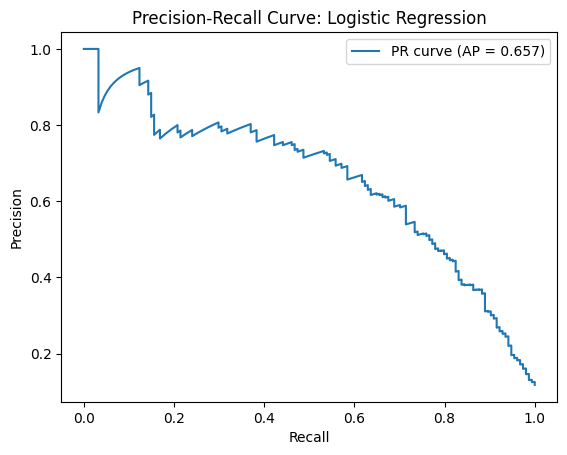

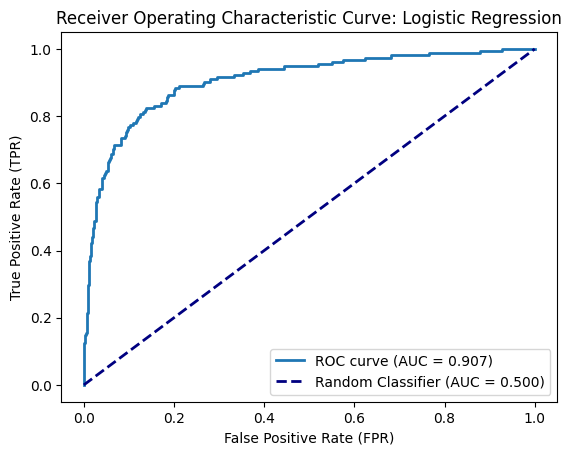

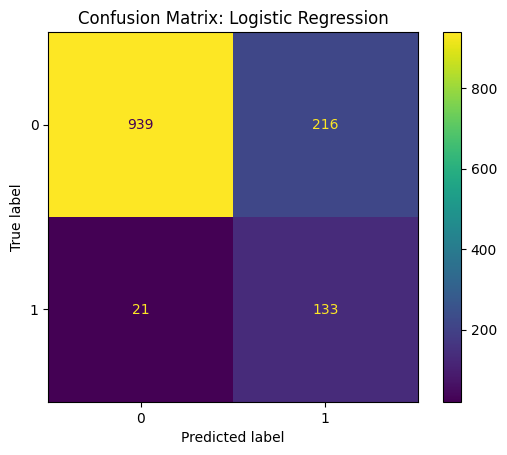


>>> Processing Model: Support Vector Machine <<<

Best parameters: SVC(C=10, class_weight='balanced', probability=True)

Results:
AP=0.671, ROC-AUC=0.891, F1=0.613, MCC=0.563
Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.91      0.94      1155
         1.0       0.52      0.75      0.61       154

    accuracy                           0.89      1309
   macro avg       0.74      0.83      0.77      1309
weighted avg       0.91      0.89      0.90      1309



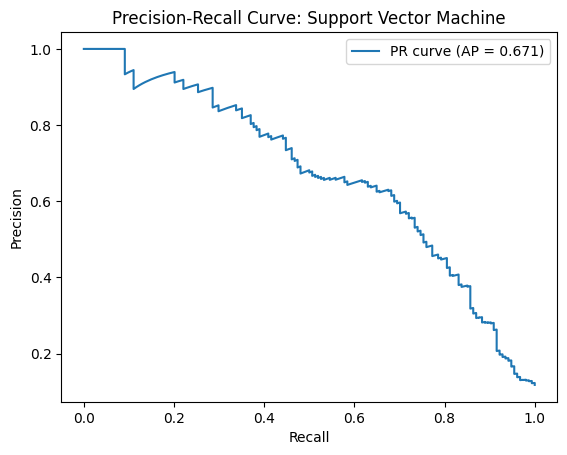

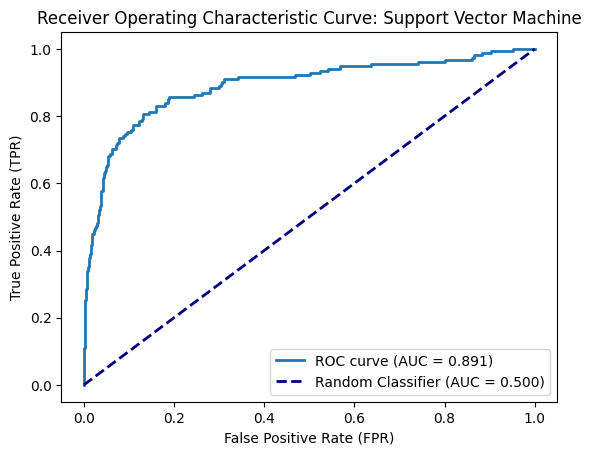

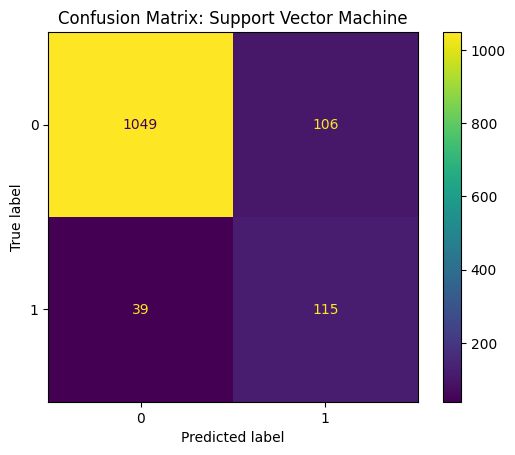


>>> Processing Model: Random Forest <<<

Best parameters: RandomForestClassifier(class_weight='balanced', n_estimators=300)

Results:
AP=0.673, ROC-AUC=0.919, F1=0.441, MCC=0.458
Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.99      0.95      1155
         1.0       0.80      0.31      0.44       154

    accuracy                           0.91      1309
   macro avg       0.86      0.65      0.70      1309
weighted avg       0.90      0.91      0.89      1309



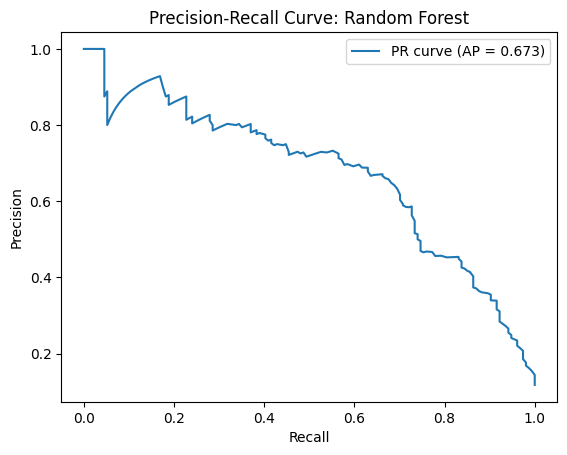

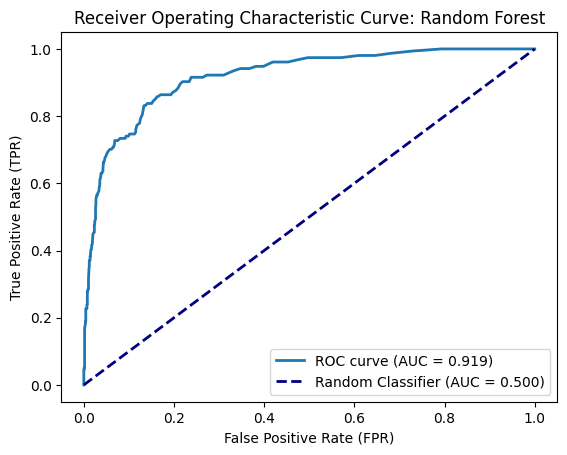

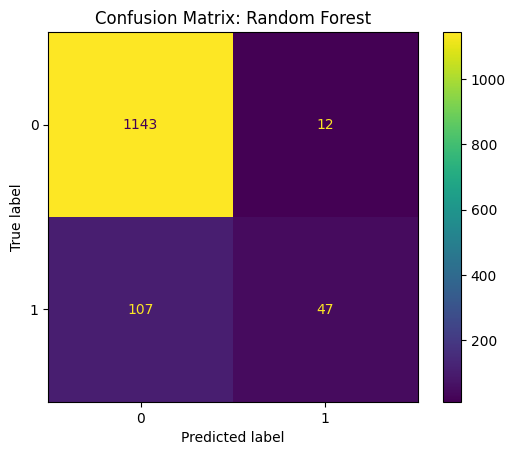

In [60]:
# training using molecular descriptors

desc = model_training(models, "mol_descriptors", desc_X_train_selected, desc_X_test_selected, y_train, y_test)

In [61]:
# results of molecular descriptors

print(desc)

desc.to_csv("results/mol_descriptors.csv")

                    Model    PR-AUC   ROC-AUC        F1       MCC
2           Random Forest  0.672931  0.918550  0.441315  0.457831
1  Support Vector Machine  0.671197  0.890814  0.613333  0.563336
0     Logistic Regression  0.657179  0.906763  0.528827  0.493004


## **Feature extraction of Morgan Fingerprints**

In [62]:
# extracting morgan fingerprints

mfp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

morgan_fingerprints = []
for smiles in NR_AhR_df["smiles"]:
    mol = Chem.MolFromSmiles(smiles)
    fp = list(mfp_gen.GetFingerprint(mol))
    morgan_fingerprints.append(fp)

column_names = [f"Morgan_Bit_{i+1}" for i in range(2048)]
morgan_fingerprints_df = pd.DataFrame(morgan_fingerprints, columns=column_names)

print(f"Generated fingerprints for {morgan_fingerprints_df.shape[0]} molecules.")
morgan_fingerprints_df.head()

[21:42:25] WARNING: not removing hydrogen atom without neighbors


Generated fingerprints for 6542 molecules.


,Morgan_Bit_1,Morgan_Bit_2,Morgan_Bit_3,Morgan_Bit_4,Morgan_Bit_5,Morgan_Bit_6,Morgan_Bit_7,Morgan_Bit_8,Morgan_Bit_9,Morgan_Bit_10,...,Morgan_Bit_2039,Morgan_Bit_2040,Morgan_Bit_2041,Morgan_Bit_2042,Morgan_Bit_2043,Morgan_Bit_2044,Morgan_Bit_2045,Morgan_Bit_2046,Morgan_Bit_2047,Morgan_Bit_2048
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
# train/test split (fp_X)

fp_X = morgan_fingerprints_df.copy()
y = NR_AhR_df["NR-AhR"]

fp_X_train = fp_X.loc[train_idx]
fp_X_test = fp_X.loc[test_idx]

In [64]:
# saving datasets used for morgan fingerprints

DATA_DIR = Path("data/processed/fingerprints")
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_to_save = {
    "fp_X_train": fp_X_train,
    "fp_X_test": fp_X_test,
    "y_train": y_train,
    "y_test": y_test,
}

for name, df in data_to_save.items():
    df.to_csv(DATA_DIR / f"{name}.csv")


>>> Processing Model: Logistic Regression <<<

Best parameters: LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000, penalty='l2',
                   solver='liblinear')

Results:
AP=0.645, ROC-AUC=0.907, F1=0.592, MCC=0.549
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.88      0.92      1155
         1.0       0.47      0.81      0.59       154

    accuracy                           0.87      1309
   macro avg       0.72      0.84      0.76      1309
weighted avg       0.91      0.87      0.88      1309



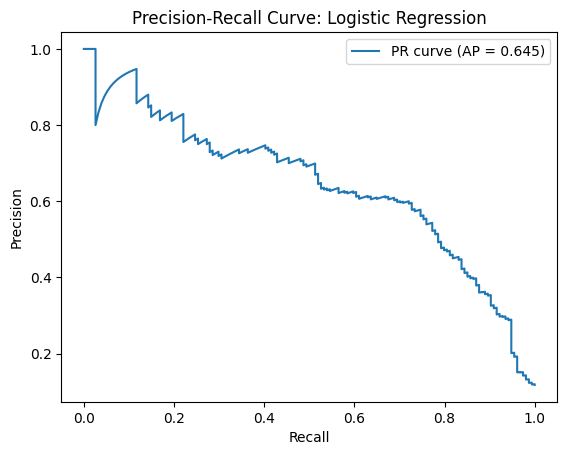

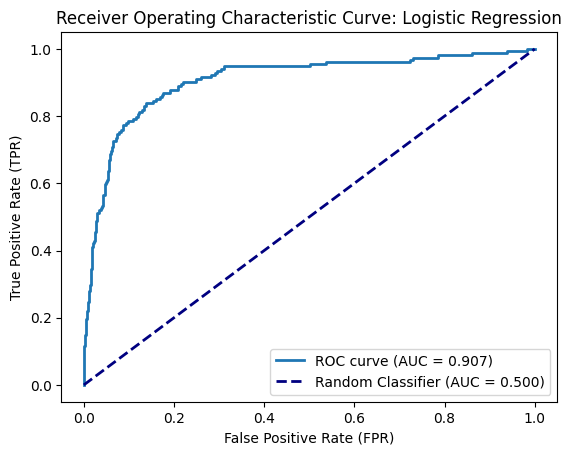

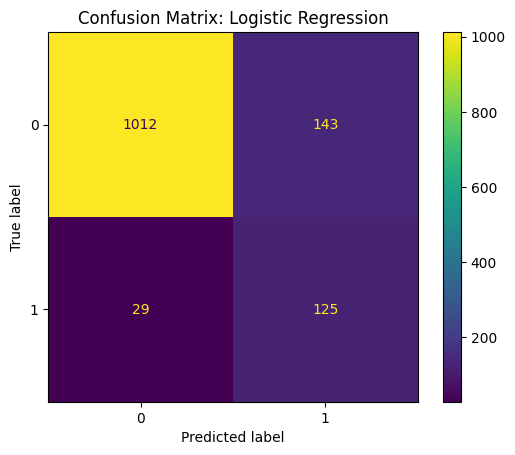


>>> Processing Model: Support Vector Machine <<<

Best parameters: SVC(C=1, class_weight='balanced', probability=True)

Results:
AP=0.659, ROC-AUC=0.912, F1=0.635, MCC=0.584
Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.93      0.95      1155
         1.0       0.58      0.69      0.64       154

    accuracy                           0.91      1309
   macro avg       0.77      0.81      0.79      1309
weighted avg       0.91      0.91      0.91      1309



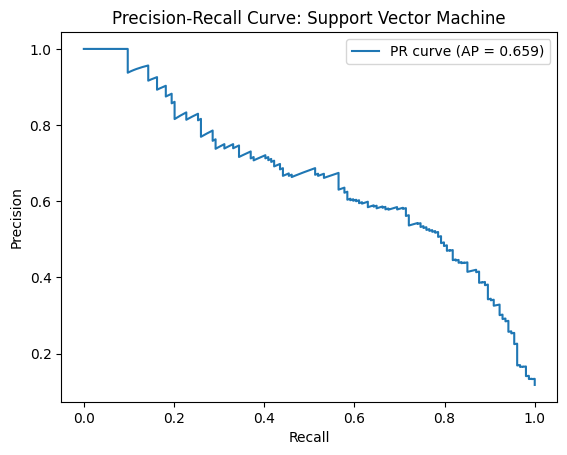

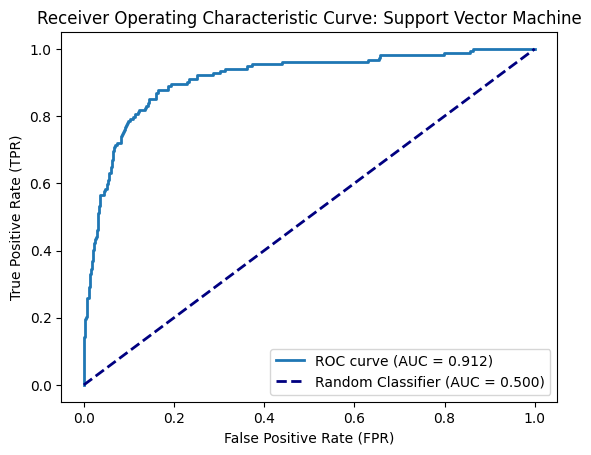

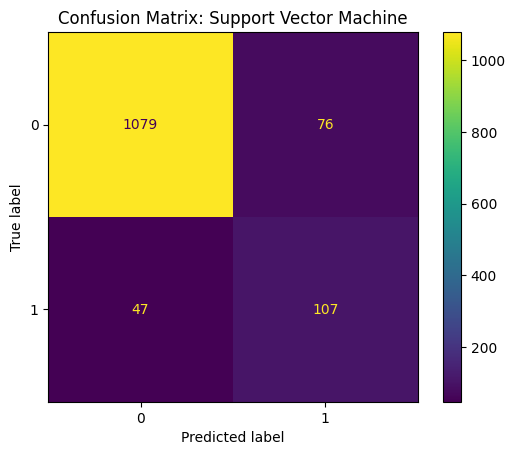


>>> Processing Model: Random Forest <<<

Best parameters: RandomForestClassifier(class_weight='balanced', n_estimators=300)

Results:
AP=0.669, ROC-AUC=0.918, F1=0.495, MCC=0.502
Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.99      0.95      1155
         1.0       0.81      0.36      0.50       154

    accuracy                           0.91      1309
   macro avg       0.86      0.67      0.72      1309
weighted avg       0.91      0.91      0.90      1309



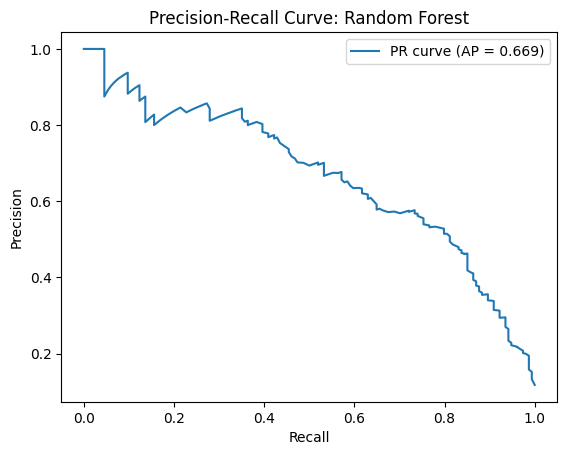

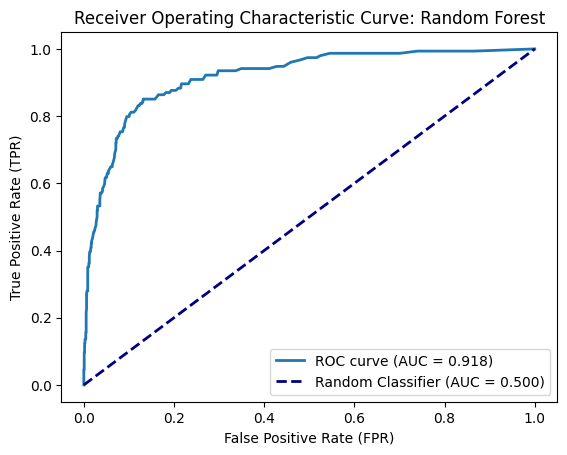

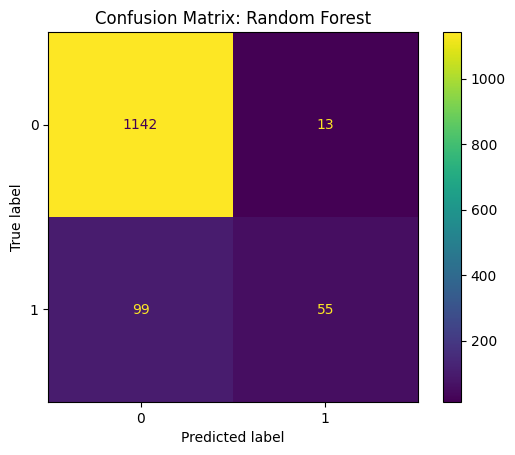

In [65]:
# training using morgan fingerprints

fp = model_training(models, "morgan_fp", fp_X_train, fp_X_test, y_train, y_test)

In [66]:
# results of morgan fingerprints

print(fp)

fp.to_csv("results/morgan_fp.csv")

                    Model    PR-AUC   ROC-AUC        F1       MCC
2           Random Forest  0.668742  0.918384  0.495495  0.502164
1  Support Vector Machine  0.658536  0.912335  0.635015  0.584400
0     Logistic Regression  0.645112  0.907202  0.592417  0.549251


## **Model with both**

In [67]:
# checking alignment between training/testing set of mol descriptors and training/testing set of morgan fp

(desc_X_train_selected.index == fp_X_train.index).all()
(desc_X_test_selected.index == fp_X_test.index).all()

np.True_

In [68]:
# concatenate training/testing sets of mol descriptors and morgan fp

X_train = pd.concat([desc_X_train_selected, fp_X_train], axis=1)
X_test  = pd.concat([desc_X_test_selected, fp_X_test], axis=1)

In [69]:
# saving datasets used for mixed features

DATA_DIR = Path("data/processed/mixed")
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_to_save = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,
}

for name, df in data_to_save.items():
    df.to_csv(DATA_DIR / f"{name}.csv")


>>> Processing Model: Logistic Regression <<<

Best parameters: LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000, penalty='l2',
                   solver='liblinear')

Results:
AP=0.721, ROC-AUC=0.918, F1=0.610, MCC=0.574
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.87      0.92      1155
         1.0       0.47      0.86      0.61       154

    accuracy                           0.87      1309
   macro avg       0.73      0.86      0.77      1309
weighted avg       0.92      0.87      0.89      1309



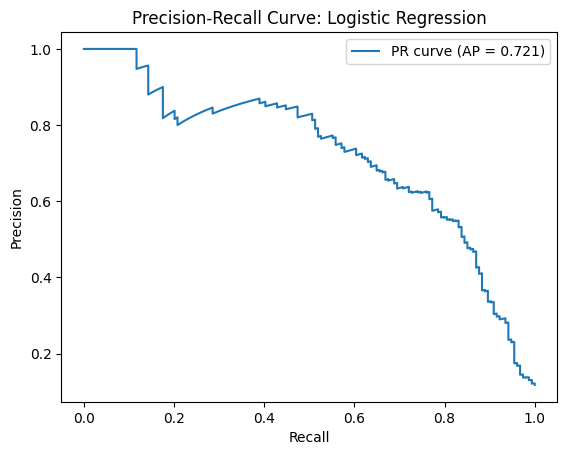

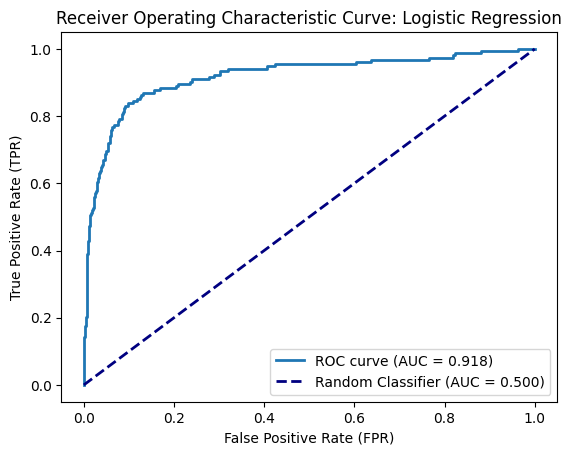

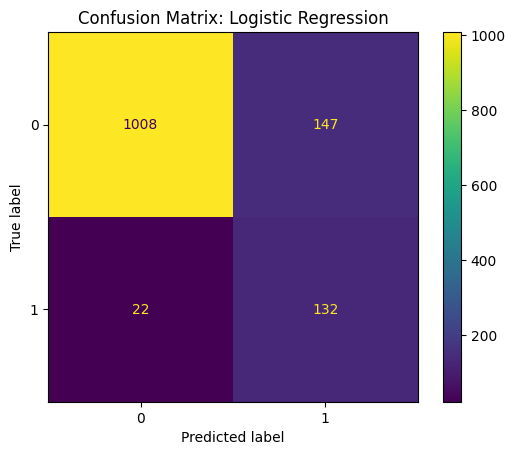


>>> Processing Model: Support Vector Machine <<<

Best parameters: SVC(C=10, class_weight='balanced', probability=True)

Results:
AP=0.713, ROC-AUC=0.908, F1=0.632, MCC=0.583
Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.95      0.95      1155
         1.0       0.64      0.62      0.63       154

    accuracy                           0.91      1309
   macro avg       0.79      0.79      0.79      1309
weighted avg       0.91      0.91      0.91      1309



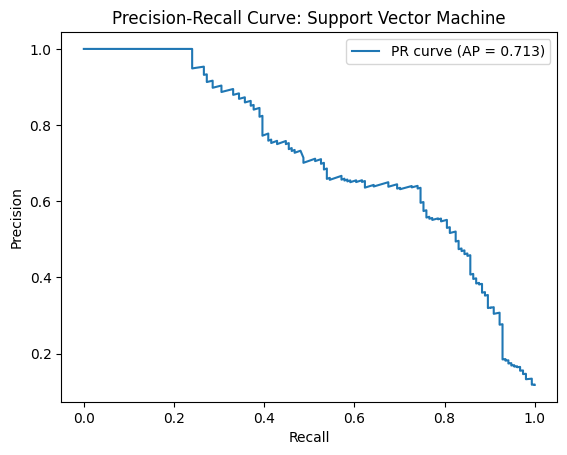

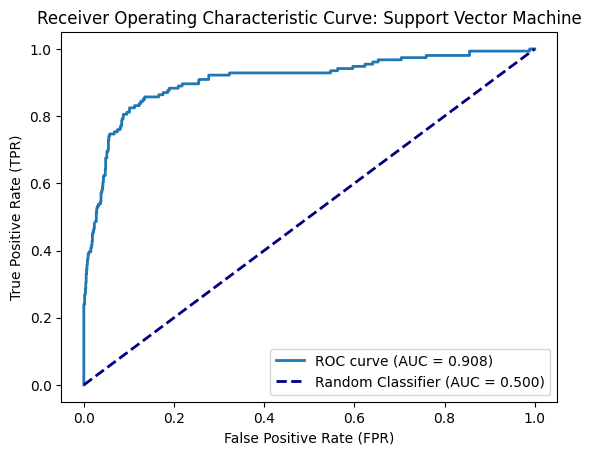

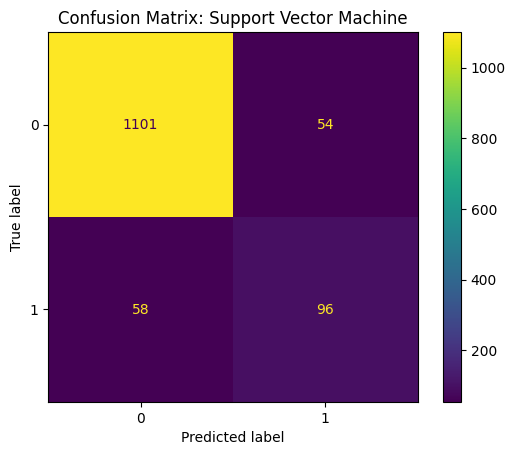


>>> Processing Model: Random Forest <<<

Best parameters: RandomForestClassifier(class_weight='balanced', n_estimators=300)

Results:
AP=0.717, ROC-AUC=0.930, F1=0.518, MCC=0.534
Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.99      0.96      1155
         1.0       0.86      0.37      0.52       154

    accuracy                           0.92      1309
   macro avg       0.89      0.68      0.74      1309
weighted avg       0.92      0.92      0.90      1309



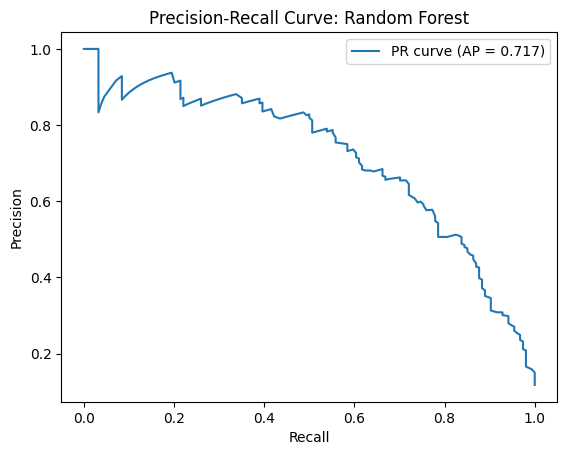

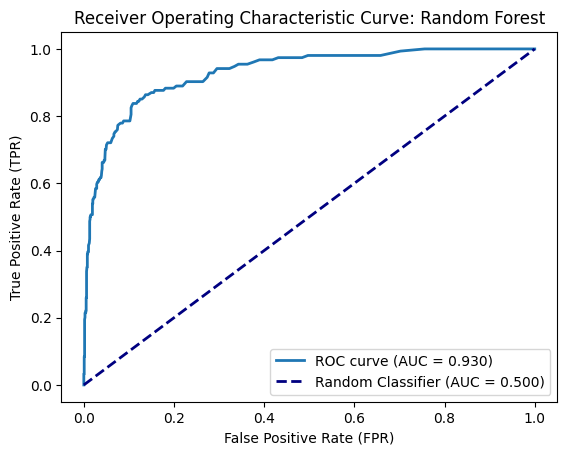

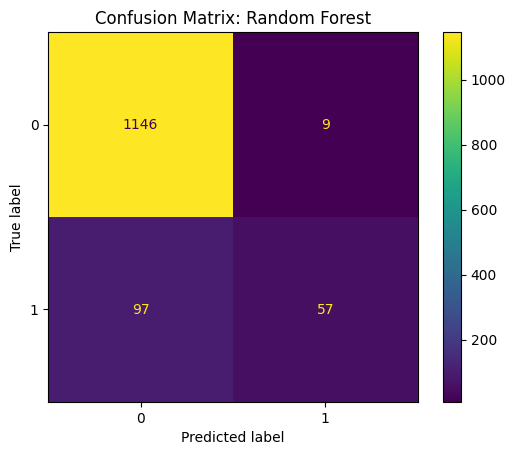

In [70]:
# training using mixed features

mixed = model_training(models, "mixed", X_train, X_test, y_train, y_test)

In [71]:
# results of mixed features

print(mixed)

mixed.to_csv("results/mixed.csv")

                    Model    PR-AUC   ROC-AUC        F1       MCC
0     Logistic Regression  0.720533  0.918474  0.609700  0.574217
2           Random Forest  0.716580  0.929614  0.518182  0.533528
1  Support Vector Machine  0.713314  0.908295  0.631579  0.583252


In [72]:
# print final results

df = pd.concat(
    [desc.assign(Run="desc"), fp.assign(Run="fp"), mixed.assign(Run="mixed")],
    ignore_index=True
)

df["Model"] = df["Model"] + " " + df["Run"]
df = df.sort_values(by="PR-AUC", ascending=False).drop(columns="Run")

print(df)

df.to_csv("results/best_models.csv")

                          Model    PR-AUC   ROC-AUC        F1       MCC
6     Logistic Regression mixed  0.720533  0.918474  0.609700  0.574217
7           Random Forest mixed  0.716580  0.929614  0.518182  0.533528
8  Support Vector Machine mixed  0.713314  0.908295  0.631579  0.583252
0            Random Forest desc  0.672931  0.918550  0.441315  0.457831
1   Support Vector Machine desc  0.671197  0.890814  0.613333  0.563336
3              Random Forest fp  0.668742  0.918384  0.495495  0.502164
4     Support Vector Machine fp  0.658536  0.912335  0.635015  0.584400
2      Logistic Regression desc  0.657179  0.906763  0.528827  0.493004
5        Logistic Regression fp  0.645112  0.907202  0.592417  0.549251
